In [2]:
# Importación de librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import yfinance as yf 
from scipy.optimize import minimize

In [3]:
# Obtener precios
tikers= ["AAPL", "MSFT", "GOOG"]
prices= yf.download(tikers, start= '2020-01-01', end= "2026-01-23")["Close"]

prices

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOG,MSFT
Date,,,
2020-01-02,72.400513,67.859543,152.158386
2020-01-03,71.696655,67.526543,150.263748
2020-01-06,72.267921,69.191559,150.652176
2020-01-07,71.928047,69.148376,149.278580
2020-01-08,73.085114,69.693291,151.656311
...,...,...,...
2026-01-15,257.968597,333.160004,455.620087
2026-01-16,255.291122,330.339996,458.812775
2026-01-20,246.469376,322.160004,453.484924


In [68]:
##, rendimientos 
rets=prices.pct_change().dropna()
media_diaria= rets.mean()

media_diaria_vector = rets.mean().values

# matriz de covarianza 
covarianza_matriz=rets.cov()

covarianza_matriz




Ticker,AAPL,GOOG,MSFT
Ticker,,,
AAPL,0.000399,0.000252,0.000262
GOOG,0.000252,0.000412,0.000262
MSFT,0.000262,0.000262,0.000345


In [88]:
num_portafolios = 10000
resultados = np.zeros((3, num_portafolios))

In [89]:
rf = 0.04  # tasa libre de riesgo anual

In [97]:

for i in range(num_portafolios):
    
    # Generar pesos aleatorios que sumen 1 o basicamenet 1/n
    w = np.random.random(3)
    w /= np.sum(pesos)
    
    # Rendimiento esperado anual
    rendimiento = np.sum(media_diaria * w) * 252
    
    # Riesgo anual
    riesgo = np.sqrt(np.dot(w.T, np.dot(covarianza * 252, w)))
    
    # Sharpe Ratio
    sharpe = (rendimiento - rf) / riesgo
    
    resultados[0,i] = riesgo
    resultados[1,i] = rendimiento
    resultados[2,i] = sharpe

In [98]:
# Menor riesgo
min_riesgo = np.argmin(resultados[0])
# Mayor rendimiento
max_rend = np.argmax(resultados[1])
# Mayor Sharpe
max_sharpe = np.argmax(resultados[2])




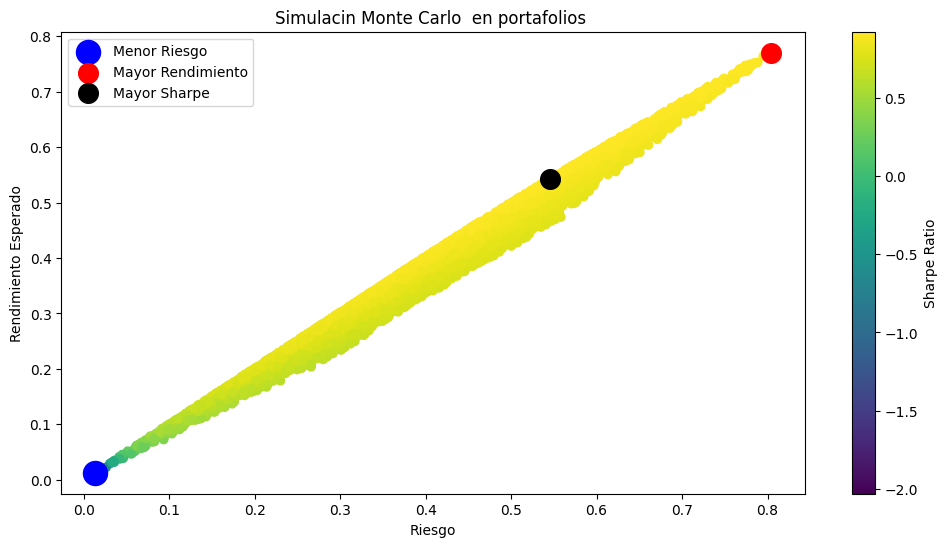

In [105]:
plt.figure(figsize=(12,6))
plt.scatter(resultados[0], resultados[1], 
            c=resultados[2], cmap='viridis')

# ponemos un ratio del sarpe para ver su colorimetri 
plt.colorbar(label='Sharpe Ratio')

#puntos especiales
plt.scatter(resultados[0,min_riesgo], resultados[1,min_riesgo], 
            color='blue', s=300, label='Menor Riesgo')

plt.scatter(resultados[0,max_rend], resultados[1,max_rend], 
            color='red', s=200, label='Mayor Rendimiento')

plt.scatter(resultados[0,max_sharpe], resultados[1,max_sharpe], 
            color='black', s=200, label='Mayor Sharpe')

plt.xlabel('Riesgo')
plt.ylabel('Rendimiento Esperado')
plt.title('Simulacin Monte Carlo  en portafolios ')
plt.legend()
plt.show()


El mejor portafolio es de acuerdo  a lo que el inversor quiera sin embargo yo me qudaria con el de sherpe  pues ya que este es una medida que indica por cada unidad de reisgo que estoy asuminedo cuanto rendimeinto estoy obteniendo, por su parte de acuerdo a la grafica es bueno. 
Si eres una persona con mucha adversion al riesgo deberias quedarte con el portafolio rojo ya que estarias teniendo aun mas rendimeintos, son embargo tu nivel de riesgo aumente aun mas. 